In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from dotmap import DotMap

import pylbsr.notebooks
import pylbsr.misc

import torch
from parnet_additional_utils import GzListDataset
from scipy.stats import pearsonr, spearmanr
import numpy as np

import parnet
from parnet_additional_utils import load_parnet_model, ParnetModelName
from parnet.layers import LinearProjectionHead
from parnet.utils import count_trainable_params

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
Seed set to 42


In [ ]:
_notebook_name = "04_evaluate_runs.ipynb"
_notebook_path = f"notebooks/globalclip-head/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[09:31:38] INFO - Project directory: /mnt/storage1/workspace/lhofer/parnet--globalclip-head


RUN ONE MODEL ON TEST DATASET

In [3]:
### RUN ON TEST DATASET AND CALCULATE CORRELATIONS

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

[09:31:41] INFO - Using device: cuda:0


⏱ 0.01 s (00:00:00)


In [5]:
# ── Select which run to evaluate on which test set ───────────────────────────────────
EVAL_RUN = "parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50" # ADAPT

# Pretrained backbone this run was fine-tuned from
PRETRAINED_MODEL = ParnetModelName.PARNET_21M_5_0   # ADAPT — or PARNET_21M_NONE / PARNET_21M_5_0

_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())
DATA_PATH = Path(_fp_cfg["global_clip"]["data_lysate_noNHS_filtered"]) # ADAPT

logger.info(f"Evaluating run: {EVAL_RUN}")
logger.info(f"Test data: {DATA_PATH}")

RUNS_DIR = PROJECT_DIR / "results" / "globalclip-head" / "training"

[09:34:15] INFO - Evaluating run: parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50
[09:34:15] INFO - Test data: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/datasets/globalclip_lysate_noNHS.minreads3.maxsignal1000.pt


⏱ 0.01 s (00:00:00)


In [6]:
# ── Load test dataset ──────────────────────────────────────────────────────────
test_ds = GzListDataset(
    DATA_PATH, split="test",
    length=600, total_key="globalCLIP", control_key="control",
    shuffle=False, mmap=True,
)
logger.info(f"Test size: {len(test_ds)}")

# ── Load best model ────────────────────────────────────────────────────────────
_model_path = RUNS_DIR / EVAL_RUN / "model.statedict.pt"
checkpoint = torch.load(_model_path, map_location=device)
logger.info(f"Loaded model from: {_model_path}")
logger.info(f"Model config: {checkpoint['model_config']}")

Loading (mmap) globalclip_lysate_noNHS.minreads3.maxsignal1000.pt split='test'... 

[09:34:28] INFO - Test size: 4896


loaded 4896 samples.


[09:34:29] INFO - Loaded model from: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/model.statedict.pt
[09:34:29] INFO - Model config: {'parnet_model_name': 'parnet.21m-5.0', 'head': 'GlobalCLIPHead', 'num_tasks': 1, 'finetuning_strategy': 'unfreeze_last_n_layers', 'use_control': False}


⏱ 10.13 s (00:00:10)


In [7]:
# ── Rebuild model architecture ─────────────────────────────────────────────────
_pretrained_path = Path(_fp_cfg["models"][PRETRAINED_MODEL.value])

model = load_parnet_model(
    PRETRAINED_MODEL,
    _pretrained_path,
    dtype=torch.float32,
    device=device,
)

class GlobalCLIPHead(torch.nn.Module):
    def __init__(self, num_tasks=1):
        super().__init__()
        self.projection = LinearProjectionHead(num_tasks)

    def forward(self, inputs, **kwargs):
        logit = self.projection(inputs)
        logprob = logit - torch.logsumexp(logit, dim=-1, keepdim=True)
        return {
            'total': logprob,
            'mix_coeff': torch.ones(inputs.shape[0], 1, device=inputs.device),
        }

model.head = GlobalCLIPHead(num_tasks=1).to(device)

# Initialize lazy parameters — derive hidden dim from the backbone (512 for 7M, 768 for 21M)
with torch.no_grad():
    _probe_seq = test_ds[0]["inputs"]["sequence"].unsqueeze(0).to(device)
    _backbone_out = model.body(model.stem(_probe_seq))
    model.head(_backbone_out)

model.load_state_dict(checkpoint["state_dict"])
model.eval()
logger.info(f"Model ready — params: {count_trainable_params(model):,}")

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(
[09:34:46] INFO - Model ready — params: 21,301,248


⏱ 0.82 s (00:00:00)


In [8]:
# ── Run inference on test set ──────────────────────────────────────────────────
pearson_scores = []
spearman_scores = []

model.eval()
with torch.no_grad():
    for i in range(len(test_ds)):
        sample = test_ds[i]
        
        # prepare input
        seq = sample["inputs"]["sequence"].unsqueeze(0).to(device)  # (1, 4, 600)
        
        # forward pass
        y_pred = model(sequence=seq)
        pred = y_pred["total"].squeeze().cpu().numpy()  # (600,)
        
        # get target signal
        target = sample["outputs"]["total"].squeeze().cpu().numpy()  # (600,)
        
        # skip windows where target is all zeros
        if target.sum() == 0:
            continue
        
        # compute correlations
        pearson_scores.append(pearsonr(pred, target)[0])
        spearman_scores.append(spearmanr(pred, target)[0])

print(f"Test samples evaluated: {len(pearson_scores)}")
print(f"Pearson  — mean: {np.mean(pearson_scores):.4f}  median: {np.median(pearson_scores):.4f}")
print(f"Spearman — mean: {np.mean(spearman_scores):.4f}  median: {np.median(spearman_scores):.4f}")

Test samples evaluated: 4896
Pearson  — mean: 0.2603  median: 0.2627
Spearman — mean: 0.2941  median: 0.2767
⏱ 18.82 s (00:00:18)


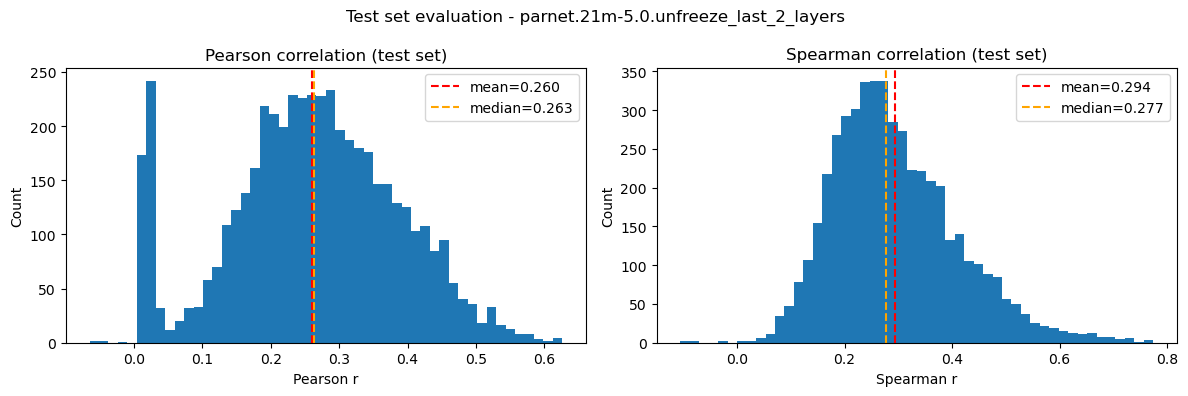

⏱ 0.79 s (00:00:00)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pearson_scores, bins=50)
axes[0].axvline(np.mean(pearson_scores), color='red', linestyle='--', label=f'mean={np.mean(pearson_scores):.3f}')
axes[0].axvline(np.median(pearson_scores), color='orange', linestyle='--', label=f'median={np.median(pearson_scores):.3f}')
axes[0].set_title('Pearson correlation (test set)')
axes[0].set_xlabel('Pearson r')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(spearman_scores, bins=50)
axes[1].axvline(np.mean(spearman_scores), color='red', linestyle='--', label=f'mean={np.mean(spearman_scores):.3f}')
axes[1].axvline(np.median(spearman_scores), color='orange', linestyle='--', label=f'median={np.median(spearman_scores):.3f}')
axes[1].set_title('Spearman correlation (test set)')
axes[1].set_xlabel('Spearman r')
axes[1].set_ylabel('Count')
axes[1].legend()

_run_label = EVAL_RUN.split(".globalclip")[0]
plt.suptitle(f"Test set evaluation - {_run_label}")
plt.tight_layout()

# ── Save to run folder and central figures dir ─────────────────────────────────
_figures_dir = PROJECT_DIR / "results" / "globalclip-head" / "figures"
_figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(RUNS_DIR / EVAL_RUN / "test_correlations.png", dpi=150, bbox_inches="tight")
plt.savefig(_figures_dir / f"test_correlations.{_run_label}.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# ── Save summary statistics ────────────────────────────────────────────────────
eval_results = {
    "run": EVAL_RUN,
    "n_test_samples": len(pearson_scores),
    "pearson_mean": round(float(np.mean(pearson_scores)), 4),
    "pearson_median": round(float(np.median(pearson_scores)), 4),
    "spearman_mean": round(float(np.mean(spearman_scores)), 4),
    "spearman_median": round(float(np.median(spearman_scores)), 4),
}

_eval_path = RUNS_DIR / EVAL_RUN / "test_evaluation.yaml"
_eval_path.write_text(yaml.dump(eval_results, default_flow_style=False))

# ── Save full per-sequence distributions ───────────────────────────────────────
np.save(RUNS_DIR / EVAL_RUN / "test_pearson_scores.npy", np.array(pearson_scores))
np.save(RUNS_DIR / EVAL_RUN / "test_spearman_scores.npy", np.array(spearman_scores))

logger.info(f"Saved evaluation results → {_eval_path}")
print(pd.DataFrame([eval_results]).to_string(index=False))

[09:36:35] INFO - Saved evaluation results → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/test_evaluation.yaml


                                                                               run  n_test_samples  pearson_mean  pearson_median  spearman_mean  spearman_median
parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50            4896        0.2603          0.2627         0.2941           0.2767
⏱ 0.06 s (00:00:00)
